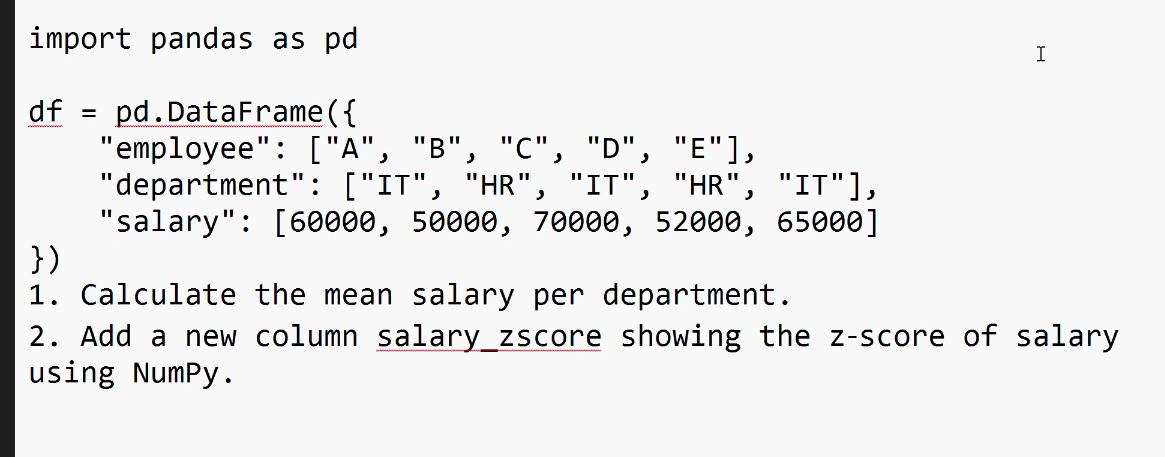

In [ ]:
import numpy as np
df.groupby("department")["salary"].mean()

zscore = x-mean/std_dev

salary_mean = df["slary"].mean()
std_dev = 


df["salary_zscore"] = 


In [ ]:

from langchain import init_chat_model
from langchain_core import HumanMessage, AIMessage, SystemMessage

template = 


model = "gpt40-mini"

messages = [
    ()
]

chat_model = init_chat_model()

cha










In [4]:
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def __str__(self):
        """Returns a user-friendly, human-readable string."""
        return f"Rectangle (Width: {self.width}, Height: {self.height})"

    def __repr__(self):
        """Returns an unambiguous string for developers, ideally to recreate the object."""
        return f"Rectangle({self.width!r}, {self.height!r})"
    

r1 = Rectangle(10, 5)

print(r1)

Rectangle (Width: 10, Height: 5)


In [5]:
r1

Rectangle(10, 5)

In [6]:
from abc import ABC, abstractmethod
from typing import List, Any
from datetime import datetime


# --- Observer Interface ---
class PipelineObserver(ABC):
    """All observers must implement this interface."""

    @abstractmethod
    def on_event(self, event_type: str, data: Any) -> None:
        pass


# --- Concrete Observers ---
class ConsoleLogger(PipelineObserver):
    """Prints events to the console."""

    def on_event(self, event_type: str, data: Any) -> None:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{timestamp}] [{event_type}] {data}")


class MetricsCollector(PipelineObserver):
    """Accumulates metrics for later analysis."""

    def __init__(self):
        self.events = []

    def on_event(self, event_type: str, data: Any) -> None:
        self.events.append({
            "timestamp": datetime.now().isoformat(),
            "event_type": event_type,
            "data": data,
        })

    def summary(self):
        return f"Collected {len(self.events)} events."


class AlertSystem(PipelineObserver):
    """Sends alerts when failures occur."""

    def on_event(self, event_type: str, data: Any) -> None:
        if event_type == "FAILURE":
            # In production, this would send an email or Slack message
            print(f"ALERT: Pipeline failure detected — {data}")


# --- Subject (the Pipeline Stage) ---
class DataPipeline:
    """
    A pipeline that processes data and notifies observers at key moments.
    It knows nothing about what the observers do.
    """

    def __init__(self):
        self._observers: List[PipelineObserver] = []

    def attach(self, observer: PipelineObserver) -> None:
        self._observers.append(observer)

    def detach(self, observer: PipelineObserver) -> None:
        self._observers.remove(observer)

    def _notify(self, event_type: str, data: Any) -> None:
        for observer in self._observers:
            observer.on_event(event_type, data)

    def run(self, records: list) -> list:
        self._notify("START", {"record_count": len(records)})
        results = []
        for i, record in enumerate(records):
            try:
                processed = self._process(record)
                results.append(processed)
                self._notify("RECORD_PROCESSED", {"index": i, "record": record})
            except Exception as e:
                self._notify("FAILURE", {"index": i, "error": str(e)})
        self._notify("COMPLETE", {"processed": len(results), "total": len(records)})
        return results

    def _process(self, record):
        # Simulate some transformation
        if record.get("value") is None:
            raise ValueError("Missing 'value' field")
        return {**record, "value_doubled": record["value"] * 2}


# --- Wiring it all together ---
pipeline = DataPipeline()
logger = ConsoleLogger()
metrics = MetricsCollector()
alerts = AlertSystem()

pipeline.attach(logger)
pipeline.attach(metrics)
pipeline.attach(alerts)

records = [
    {"id": 1, "value": 10},
    {"id": 2, "value": None},   # This will trigger a failure
    {"id": 3, "value": 30},
]

pipeline.run(records)
print(metrics.summary())

[2026-04-23 10:34:59] [START] {'record_count': 3}
[2026-04-23 10:34:59] [RECORD_PROCESSED] {'index': 0, 'record': {'id': 1, 'value': 10}}
[2026-04-23 10:34:59] [FAILURE] {'index': 1, 'error': "Missing 'value' field"}
ALERT: Pipeline failure detected — {'index': 1, 'error': "Missing 'value' field"}
[2026-04-23 10:34:59] [RECORD_PROCESSED] {'index': 2, 'record': {'id': 3, 'value': 30}}
[2026-04-23 10:34:59] [COMPLETE] {'processed': 2, 'total': 3}
Collected 5 events.


# Without a Factory — messy, hard to extend
if source_type == "csv":
    reader = CSVReader(path)
elif source_type == "parquet":
    reader = ParquetReader(path)
elif source_type == "postgres":
    reader = PostgresReader(connection_string)
# This block has to be copy-pasted everywhere you need a reader

In [11]:
class DataReaderFactory:
    _registry = {}

    @classmethod
    def register(cls, name: str, reader_class):
        """Register a new reader type."""
        cls._registry[name] = reader_class

    @classmethod
    def create(cls, source_type: str, **kwargs):
        """
        Create and return a reader for the given source type.
        Raises a clear error if the type is unknown.
        """
        if source_type not in cls._registry:
            raise ValueError(
                f"Unknown source type '{source_type}'. "
                f"Available: {list(cls._registry.keys())}"
            )
        reader_class = cls._registry[source_type]
        return reader_class(**kwargs)


class CSVReader:
    def __init__(self, path: str):
        self.path = path

    def read(self):
        import csv
        with open(self.path) as f:
            return list(csv.DictReader(f))

class ParquetReader:
    def __init__(self, path: str):
        self.path = path

    def read(self):
        import pandas as pd
        return pd.read_parquet(self.path)

# Register the readers once, at startup
DataReaderFactory.register("csv", CSVReader)
DataReaderFactory.register("parquet", ParquetReader)

reader = DataReaderFactory.create("csv", path=r"C:\dev02\TechM\python\datasets\Iris.csv")
data = reader.read()



In [15]:
data[:5]

[{'Id': '1',
  'SepalLengthCm': '5.1',
  'SepalWidthCm': '3.5',
  'PetalLengthCm': '1.4',
  'PetalWidthCm': '0.2',
  'Species': 'Iris-setosa'},
 {'Id': '2',
  'SepalLengthCm': '4.9',
  'SepalWidthCm': '3.0',
  'PetalLengthCm': '1.4',
  'PetalWidthCm': '0.2',
  'Species': 'Iris-setosa'},
 {'Id': '3',
  'SepalLengthCm': '4.7',
  'SepalWidthCm': '3.2',
  'PetalLengthCm': '1.3',
  'PetalWidthCm': '0.2',
  'Species': 'Iris-setosa'},
 {'Id': '4',
  'SepalLengthCm': '4.6',
  'SepalWidthCm': '3.1',
  'PetalLengthCm': '1.5',
  'PetalWidthCm': '0.2',
  'Species': 'Iris-setosa'},
 {'Id': '5',
  'SepalLengthCm': '5.0',
  'SepalWidthCm': '3.6',
  'PetalLengthCm': '1.4',
  'PetalWidthCm': '0.2',
  'Species': 'Iris-setosa'}]

In [ ]:
reader = DataReaderFactory.create("par")
data = reader.read()

{'csv': __main__.CSVReader}

#### Why this is better

- Adding a new source type requires **zero changes** to existing code. Just create a new class and register it.
- The pipeline logic is decoupled from the creation logic.
- The factory is a single place to add validation, caching, or logging for object creation.

### The Observer Pattern

#### The Problem It Solves

A data pipeline has many stages. You want to track progress, send alerts on failure, write metrics to a dashboard, and log every step — but you do not want the pipeline stages themselves to know about all of these side effects. The Observer pattern lets components **broadcast events** without knowing who is listening.

#### Core Concept

There are two roles:

- **Subject (Observable):** The thing that does work and emits events.
- **Observer:** Anything that wants to react to those events.

In [21]:
from abc import ABC, abstractmethod
from typing import List, Any
from datetime import datetime


# --- Observer Interface ---
class PipelineObserver(ABC):
    """All observers must implement this interface."""

    @abstractmethod
    def on_event(self, event_type: str, data: Any) -> None:
        pass


# --- Concrete Observers ---
class ConsoleLogger(PipelineObserver):
    """Prints events to the console."""

    def on_event(self, event_type: str, data: Any) -> None:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{timestamp}] [{event_type}] {data}")


class MetricsCollector(PipelineObserver):
    """Accumulates metrics for later analysis."""

    def __init__(self):
        self.events = []

    def on_event(self, event_type: str, data: Any) -> None:
        self.events.append({
            "timestamp": datetime.now().isoformat(),
            "event_type": event_type,
            "data": data,
        })

    def summary(self):
        return f"Collected {len(self.events)} events."


class AlertSystem(PipelineObserver):
    """Sends alerts when failures occur."""

    def on_event(self, event_type: str, data: Any) -> None:
        if event_type == "FAILURE":
            # In production, this would send an email or Slack message
            print(f"ALERT: Pipeline failure detected — {data}")


# --- Subject (the Pipeline Stage) ---
class DataPipeline:
    """
    A pipeline that processes data and notifies observers at key moments.
    It knows nothing about what the observers do.
    """

    def __init__(self):
        self._observers: List[PipelineObserver] = []

    def attach(self, observer: PipelineObserver) -> None:
        self._observers.append(observer)

    def detach(self, observer: PipelineObserver) -> None:
        self._observers.remove(observer)

    def _notify(self, event_type: str, data: Any) -> None:
        for observer in self._observers:
            observer.on_event(event_type, data)

    def run(self, records: list) -> list:
        self._notify("START", {"record_count": len(records)})
        results = []
        for i, record in enumerate(records):
            try:
                processed = self._process(record)
                results.append(processed)
                self._notify("RECORD_PROCESSED", {"index": i, "record": record})
            except Exception as e:
                self._notify("FAILURE", {"index": i, "error": str(e)})
        self._notify("COMPLETE", {"processed": len(results), "total": len(records)})
        return results

    def _process(self, record):
        # Simulate some transformation
        if record.get("value") is None:
            raise ValueError("Missing 'value' field")
        return {**record, "value_doubled": record["value"] * 2}


# --- Wiring it all together ---
pipeline = DataPipeline()
logger = ConsoleLogger()
metrics = MetricsCollector()
alerts = AlertSystem()

pipeline.attach(logger)
pipeline.attach(metrics)
pipeline.attach(alerts)

records = [
    {"id": 1, "value": 10},
    {"id": 2, "value": None},   # This will trigger a failure
    {"id": 3, "value": 30},
]

pipeline.run(records)
print(metrics.summary())

[2026-04-24 11:31:18] [START] {'record_count': 3}
[2026-04-24 11:31:18] [RECORD_PROCESSED] {'index': 0, 'record': {'id': 1, 'value': 10}}
[2026-04-24 11:31:18] [FAILURE] {'index': 1, 'error': "Missing 'value' field"}
ALERT: Pipeline failure detected — {'index': 1, 'error': "Missing 'value' field"}
[2026-04-24 11:31:18] [RECORD_PROCESSED] {'index': 2, 'record': {'id': 3, 'value': 30}}
[2026-04-24 11:31:18] [COMPLETE] {'processed': 2, 'total': 3}
Collected 5 events.


In [18]:
names  = ["Minku", "Pinku", "Chinku"]
counter = 1
for i in names:
    print(counter, i)
    counter+=1

1 Minku
2 Pinku
3 Chinku


In [20]:
for i, name in enumerate(names, start=1):
    print(i, name)

1 Minku
2 Pinku
3 Chinku



#### Key insight

The pipeline does not import `ConsoleLogger`, `MetricsCollector`, or `AlertSystem`. It only knows about the `PipelineObserver` interface. You can add a new observer — say, a `DatabaseAuditLogger` — without touching the pipeline code at all.

#### When to use it

Use the Observer pattern when:

- Multiple components need to react to the same events.
- You want to add or remove reactions without changing the source of events.
- You are building audit trails, monitoring, or alerting systems alongside core logic.


### The Strategy Pattern

#### The Problem It Solves

Data validation rules change by context. Sales data, sensor data, and user records all need validation, but with different rules. The Strategy pattern lets you **swap algorithms (strategies) at runtime** without changing the code that uses them.

#### Core Concept

Define a family of algorithms, encapsulate each one, and make them interchangeable. The object that uses a strategy holds a reference to one, and delegates the work to it.

In [23]:
from abc import ABC, abstractmethod
from typing import List, Dict, Any

# --- Strategy Interface ---
class ValidationStrategy(ABC):
    """Every validation strategy must implement validate()."""

    @abstractmethod
    def validate(self, record: Dict[str, Any]) -> List[str]:
        """
        Validate a record.
        Returns a list of error messages. Empty list means valid.
        """
        pass

# --- Concrete Strategies ---
class SalesRecordValidator(ValidationStrategy):
    """Validates sales records."""

    def validate(self, record: Dict[str, Any]) -> List[str]:
        errors = []
        if "sale_id" not in record:
            errors.append("Missing required field: sale_id")
        if "amount" not in record or not isinstance(record["amount"], (int, float)):
            errors.append("Field 'amount' must be a number")
        if record.get("amount", 0) < 0:
            errors.append("Field 'amount' cannot be negative")
        return errors
    


class SensorReadingValidator(ValidationStrategy):
    """Validates IoT sensor readings."""

    def __init__(self, min_temp: float = -50.0, max_temp: float = 150.0):
        self.min_temp = min_temp
        self.max_temp = max_temp

    def validate(self, record: Dict[str, Any]) -> List[str]:
        errors = []
        if "sensor_id" not in record:
            errors.append("Missing required field: sensor_id")
        if "temperature" not in record:
            errors.append("Missing required field: temperature")
        elif not (self.min_temp <= record["temperature"] <= self.max_temp):
            errors.append(
                f"Temperature {record['temperature']} outside valid range "
                f"[{self.min_temp}, {self.max_temp}]"
            )
        return errors
    

class PermissiveValidator(ValidationStrategy):
    """Accepts everything — useful for development/testing."""

    def validate(self, record: Dict[str, Any]) -> List[str]:
        return []
    


# --- Context: uses a strategy ---
class DataValidator:
    """
    Validates records using an injected strategy.
    It does not know or care which strategy is being used.
    """

    def __init__(self, strategy: ValidationStrategy):
        self._strategy = strategy

    def set_strategy(self, strategy: ValidationStrategy) -> None:
        """Swap the strategy at any time."""
        self._strategy = strategy

    def validate_batch(self, records: List[Dict]) -> Dict:
        valid = []
        invalid = []
        for record in records:
            errors = self._strategy.validate(record)
            if errors:
                invalid.append({"record": record, "errors": errors})
            else:
                valid.append(record)
        return {"valid": valid, "invalid": invalid}

# --- Usage ---
sales_records = [
    {"sale_id": "S001", "amount": 250.00},
    {"sale_id": "S002", "amount": -10.00},   # invalid
    {"amount": 100.00},                       # missing sale_id
]


validator = DataValidator(strategy=SalesRecordValidator())
results = validator.validate_batch(sales_records)
print(f"Valid: {len(results['valid'])}, Invalid: {len(results['invalid'])}")


# Swap to sensor validation for a different dataset
sensor_records = [
    {"sensor_id": "T42", "temperature": 22.5},
    {"sensor_id": "T43", "temperature": 999.0},  # out of range
]

validator.set_strategy(SensorReadingValidator(min_temp=-20, max_temp=100))
results = validator.validate_batch(sensor_records)
print(f"Valid: {len(results['valid'])}, Invalid: {len(results['invalid'])}")

Valid: 1, Invalid: 2
Valid: 1, Invalid: 1



#### When to use it

Use the Strategy pattern when:

- You have multiple ways to do the same thing (sort, validate, transform, serialize).
- The choice of algorithm depends on runtime conditions (data type, user preference, environment).
- You want to avoid large `if/elif` chains that grow over time.

---

### Design Patterns — Quick Reference

|Pattern|Core Idea|Data Engineering Use Case|
|---|---|---|
|Factory|Centralise object creation|Create readers/writers for different formats|
|Observer|Broadcast events to listeners|Pipeline monitoring, alerting, audit logging|
|Strategy|Swap algorithms at runtime|Validation rules, transformation logic, output formats|


In [26]:
import threading
import time

counter = 0

def increment():
    global counter
    for _ in range(100_000):
        temp = counter
        time.sleep(0)  # force context switch
        counter = temp + 1

threads = [threading.Thread(target=increment) for _ in range(5)]
for t in threads:
    t.start()
for t in threads:
    t.join()

print(counter)  # Now you'll see inconsistent results

100704


In [27]:
import threading

counter = 0
lock = threading.Lock()

def increment():
    global counter
    for _ in range(100_000):
        with lock:
            counter += 1

threads = [threading.Thread(target=increment) for _ in range(5)]
for t in threads:
    t.start()
for t in threads:
    t.join()

print(counter)  # Always correct


500000


In [ ]:
# HW: Create a timer decorator

In [3]:
import threading
import time

def download_file(filename):
    print(f"Starting download: {filename}")
    time.sleep(2)  # Simulates waiting for network I/O
    print(f"Finished download: {filename}")

# Sequential — takes 6 seconds total
for name in ["file1.txt", "file2.txt", "file3.txt"]:
    download_file(name)

Starting download: file1.txt
Finished download: file1.txt
Starting download: file2.txt
Finished download: file2.txt
Starting download: file3.txt
Finished download: file3.txt


In [5]:


# Concurrent with threads — takes ~2 seconds total

threads = []
for name in ["file1.txt", "file2.txt", "file3.txt"]:
    t = threading.Thread(target=download_file, args=(name,))
    threads.append(t)
    t.start()

# Wait for all threads to finish
for t in threads:
    t.join()

Starting download: file1.txt
Starting download: file2.txt
Starting download: file3.txt
Finished download: file1.txt
Finished download: file2.txt
Finished download: file3.txt


In [ ]:
# scope in python 

In [8]:
import threading

counter = 0  # Shared variable

def increment():
    global counter
    for _ in range(100_000):
        temp = counter
        time.sleep(0)
        counter = temp +1
          # NOT thread-safe! Read-modify-write in 3 steps

threads = [threading.Thread(target=increment) for _ in range(5)]
for t in threads:
    t.start()


    
for t in threads:
    t.join()

print(counter)  # Expected: 500,000. Actual: unpredictable (e.g., 312,847)

100291


In [9]:
import threading

counter = 0
lock = threading.Lock()

def increment():
    global counter
    for _ in range(100_000):
        with lock:  # Only one thread can be inside this block at a time
            counter += 1

threads = [threading.Thread(target=increment) for _ in range(5)]
for t in threads:
    t.start()
for t in threads:
    t.join()

print(counter)  # Always 500,000

500000


In [14]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
import asyncio

# A coroutine is defined with "async def"
# It returns a coroutine object, not a value, when called
async def greet(name, delay):
    print(f"Hello, {name}! Starting work...")
    await asyncio.sleep(delay)  # "await" = pause here, let others run
    print(f"Done with {name}!")
    return f"Result for {name}"


greet("Nickk", 3)

<coroutine object greet at 0x00000235CAB90D60>

In [16]:
# To run coroutines, you need an event loop
async def main():
    # This runs them SEQUENTIALLY — each awaits the other
    await greet("Alice", 1)
    await greet("Bob", 1)
    # Total time: 2 seconds

asyncio.run(main())

Hello, Alice! Starting work...
Done with Alice!
Hello, Bob! Starting work...
Done with Bob!


In [ ]:
from multiprocessing import Pool
import os

def cpu_heavy(n):
    # Simulate CPU work: find all primes up to n
    primes = []
    for num in range(2, n):
        if all(num % i != 0 for i in range(2, int(num**0.5) + 1)):
            primes.append(num)
    return len(primes)

numbers = [50_000, 50_000, 50_000, 50_000]

if __name__ == "__main__":  # Required on Windows/macOS
    # Sequential
    # results = [cpu_heavy(n) for n in numbers]  # Takes ~4x one run

    # Parallel — uses all available CPU cores
    with Pool() as pool:  # Pool() defaults to cpu_count() workers
        results = pool.map(cpu_heavy, numbers)  # Takes ~1x one run
    print(results)